# Лабораторная работа №4. Q-обучение

### 1. Подготовительные действия 

In [1]:
import sys, os

if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ["DISPLAY"] = ":1"
    
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math

### 2. Класс QLearningAgent

Q-Learning Agent $\\$
 Переменные экземпляра, к которым есть доступ
 - self.epsilon (исследование)
 - self.alpha (скорость обучения)
 - self.discount (дисконт, она же гамма)

 Функции
 - self.get_legal_actions(state) {состояние, хешируемое -> список действий, каждое из которых
хешируемое} который возвращает разрешенные действия для состояния
 - self.get_qvalue (состояние, действие) который возвращает Q (состояние, действие)
 - self.set_qvalue (состояние, действие, значение) который устанавливает Q (состояние, действие): = значение



In [2]:
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
       self.get_legal_actions = get_legal_actions
       self._qvalue = defaultdict(lambda: defaultdict(lambda: 0))
       self.alpha = alpha
       self.epsilon = epsilon
       self.discount = discount
       
    def get_qvalue(self, state, action):
        """Возврощает Q(state, action)"""
        return self._qvalue[state][action]
    
    def set_qvalue(self, state, action, value):
        """Устанавливает Qvaluу[state, action] в определенное значение"""
        self._qvalue[state][action] = value
        
    def get_value(self, state):
        """
        Оценку агента V(s), используя текущие значения q.
        V(s) = max_over_action Q(состояние,действие) по возможным действиям.
        """
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return 0.0
        
        value = max([self.get_qvalue(state, action) for action in possible_actions])
        return value

    def update(self, state, action, reward, next_state):
        """Обновление значнеия Q-Value"""
        gamma  = self.discount
        leatning_rate = self.alpha
        
        new_q = (1- leatning_rate)*self.get_qvalue(state, action) \
            + leatning_rate * (reward + gamma * self.get_value(next_state))
            
        self.set_qvalue(state, action, new_q)
        
    def get_best_action(self, state):
        """Возвращает наилучшее действие для состояния (используя текущие значения q)"""
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None 
        best_action = max(possible_actions, key=lambda action: self.get_qvalue(state, action))
        
        return best_action
    
    def get_action(self, state):
        """Вычислите действие, которое нужно предпринять в текущем состоянии, включая исследование"""
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None
        
        epsilon = self.epsilon
        
        if random.random() <= epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)
        
        return chosen_action

Попробуем на среде такси. Здесь мы используем агент qlearning на такси env от
openai gymnasium.

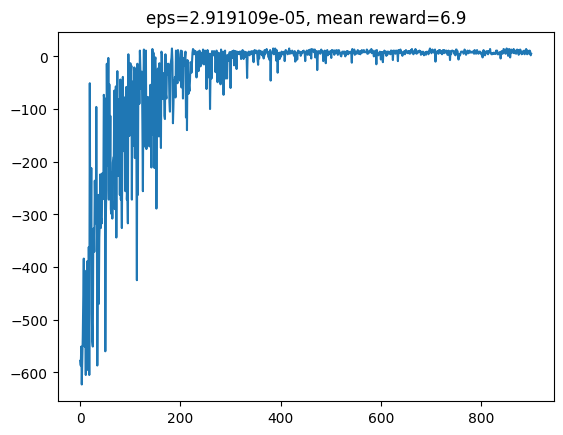

In [3]:
import gymnasium as gym
from IPython.display import clear_output

env = gym.make("Taxi-v3")
n_actions = env.action_space.n

agent = QLearningAgent(
    alpha=0.5, 
    epsilon=0.25, 
    discount=0.99, 
    get_legal_actions=lambda s: range(n_actions)
)

def play_and_train(env, agent, t_max= 10**4):
    """Игра до конца или t_max тиков"""
    total_reword = 0.0
    s, _ = env.reset()
    
    for t in range(t_max):
        a = agent.get_action(s) # Агент выберает действие 
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        
        agent.update(s, a, r, next_s) # Обучение агента
        s = next_s
        total_reword += r
        
        if done:
            break
        
    return total_reword

rewofds = []

for i in range(1000):
    rewofds.append(play_and_train(env, agent))
    agent.epsilon *= 0.99
    
    if i % 100 == 0:
        clear_output(True)
        plt.title('eps={:e}, mean reward={:.1f}'.format(agent.epsilon, np.mean(rewofds[-10:])))
        plt.plot(rewofds)
        plt.show()


### 3. Бинаризованные пространства состояний

Используем агент для эффективного обучения на CartPole-v0. Эта среда имеет непрерывный набор возможных состояний, поэтому придется каким-то образом сгруппировать их в *бины*. Самый простой способ — использовать **round(x, n_digits)** (или **np.round**) для округления действительного числа до заданного 
количества цифр. $\\ \\$

Сложность заключается в том, чтобы правильно подобрать **n_digits** для каждого состояния для эффективного обучения. Обратите внимание, что нужно преобразовывать состояние не в целые числа, а в кортежи любых значений.

first state: [ 0.03180002 -0.0295453  -0.00288188 -0.00902292]


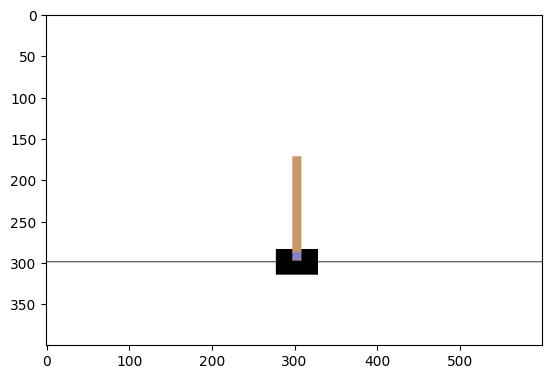

In [36]:
def make_env():
    return gym.make('CartPole-v1', render_mode='rgb_array').env  

env = make_env()
n_actions = env.action_space.n
first_state, _ = env.reset()

print(f"first state: {first_state}")
plt.imshow(env.render())

Оценим распределения наблюдений. Для этого сыграем несколько игр и запишем все состояния.

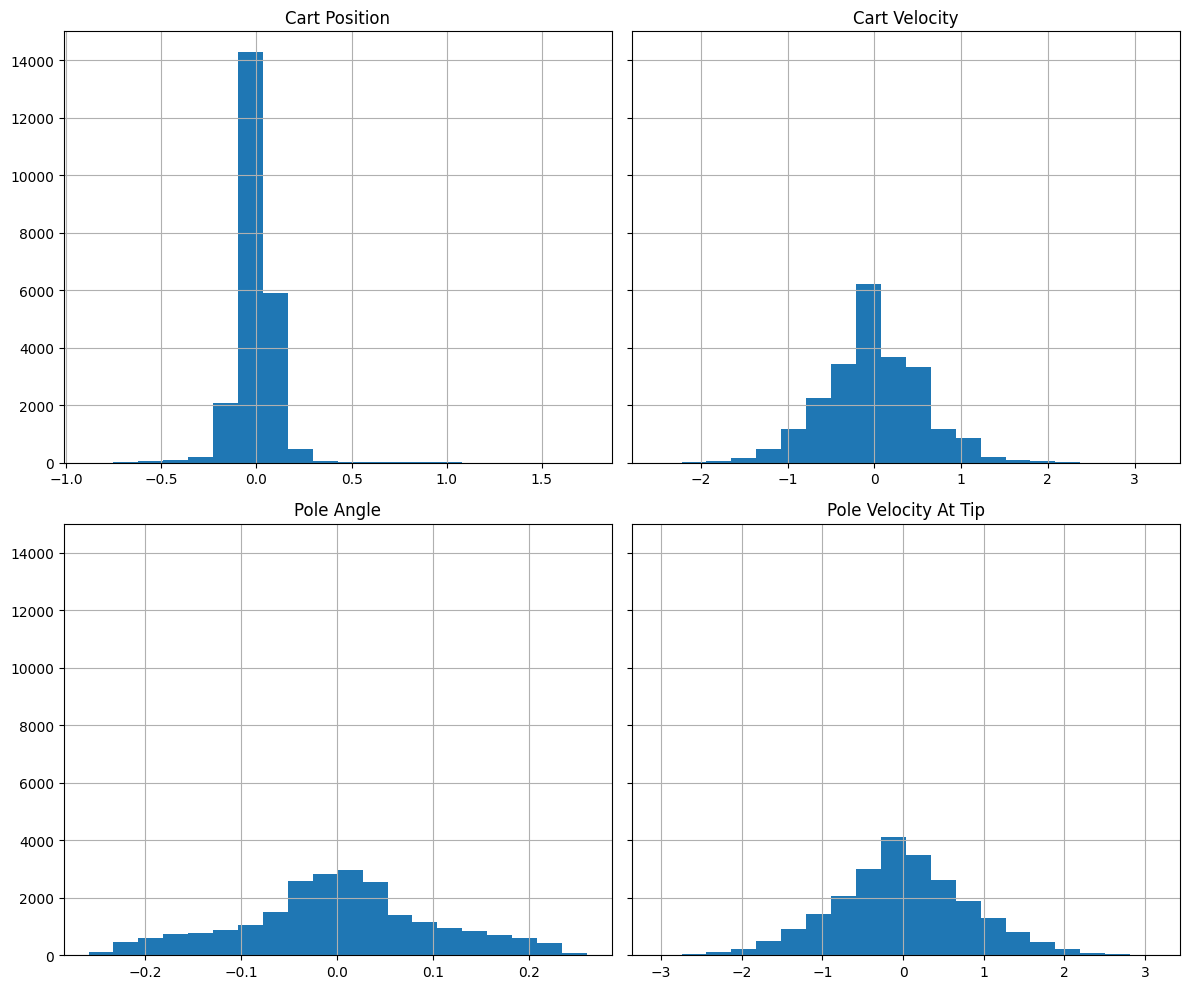

In [67]:
seen_observations = []

for _ in range(1000):
    s1, _ = env.reset()
    seen_observations.append(s1)
    done = False
    
    while not done:
        s, r, terminated, truncated, _ = env.step(env.action_space.sample())
        done = terminated or truncated
        seen_observations.append(s)

seen_observations = np.array(seen_observations)
    
obs_names = [
    'Cart Position',
    'Cart Velocity',        
    'Pole Angle',           
    'Pole Velocity At Tip'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

for obs_i in range(env.observation_space.shape[0]):
    ax = axes[obs_i]
    ax.set_title(obs_names[obs_i])
    ax.hist(seen_observations[:, obs_i], bins=20)
    ax.grid(True)
     
plt.tight_layout()   
plt.show()                       

### 4. Бинаризованная среда

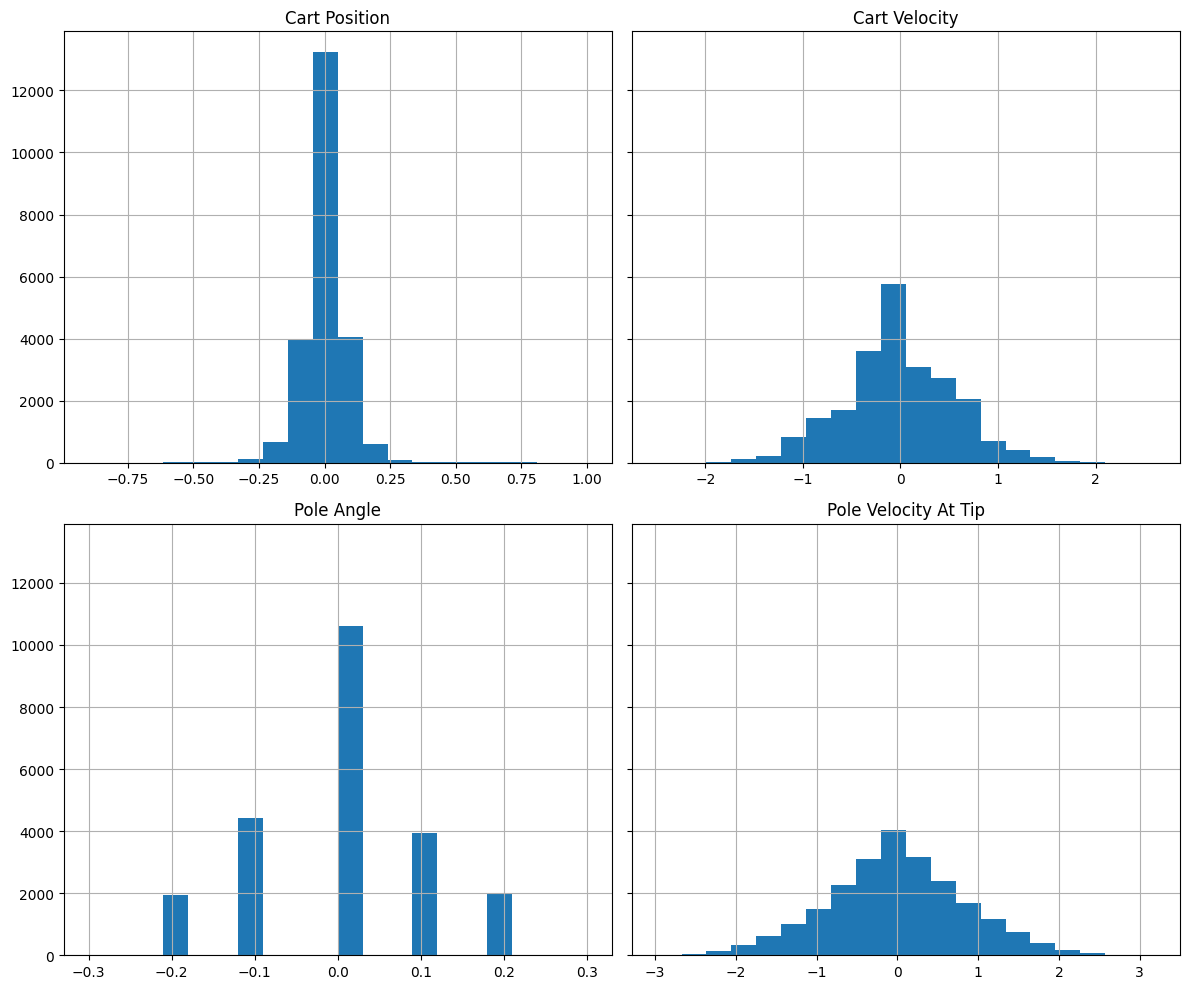

In [84]:
from gymnasium.core import ObservationWrapper

class Binarizer(ObservationWrapper):
    def observation(self, state):
        state[0] = round(state[0], 1)  # Cart Position 
        state[1] = round(state[1], 2)  # Cart Velocity
        state[2] = round(state[2], 1)  # Pole Angle
        state[3] = round(state[3], 2)  # Pole Velocity At Tip
        return tuple(state)
    
env2= Binarizer(gym.make('CartPole-v1').env)

seen_observations =  []

for _ in range(1000):
    s1, _ = env2.reset()
    seen_observations.append(s1)
    done = False
    
    while not done:
        s, r, terminated, truncated, _ = env2.step(env2.action_space.sample())
        done = terminated or truncated
        seen_observations.append(s)

seen_observations = np.array(seen_observations)
    
obs_names = [
    'Cart Position',
    'Cart Velocity',        
    'Pole Angle',           
    'Pole Velocity At Tip'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

for obs_i in range(env2.observation_space.shape[0]):
    ax = axes[obs_i]
    ax.set_title(obs_names[obs_i])
    ax.hist(seen_observations[:, obs_i], bins=20)
    ax.grid(True)
     
plt.tight_layout()   
plt.show()